# Retrieve and Display Neural/Behavioral Data

The code below selects which experiment to retrieve. Data is organized by subject/region in each experiment, with each file corresponding to an electrode array.

Data is of shape

$
X \rightarrow (T, E, N) \\
y \rightarrow (T, E, 2)
$

Where:

* **T** — number of time points per event (sampled in ms)  
* **E** — number of events  
* **N** — number of units

User can specify the experiment and is then prompted to select the appropriate file.

Data must be stored in a "data" directory at the same level as the code. Within "data," each experiment is represented as its own directory. The files are included within those folders.

In [1]:
from imports import *
from const import *
from utils import *
from loaders import *

In [ ]:
EXPERIMENT = 'Jenkins' # or Chowdhury
filename = select_file(EXPERIMENT)
X, y, behavioral_markers, marker_labels = get_all_data_from_file(EXPERIMENT, filename)
print(f'Data is of shape: {X.shape[0]} time points, {X.shape[1]} trials, {X.shape[2]} neurons')

In [ ]:
# We select a neuron index arbitrarily to simply visualize the data
n = 40
# Compute mean velocity and corresponding error
T, mean_x_vel, mean_y_vel, x_vel_err, y_vel_err = process_velocities(y)

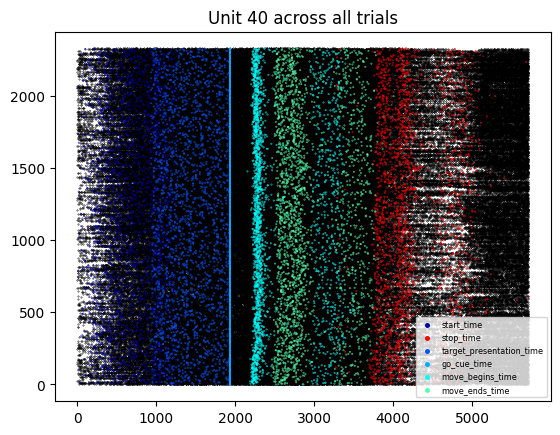

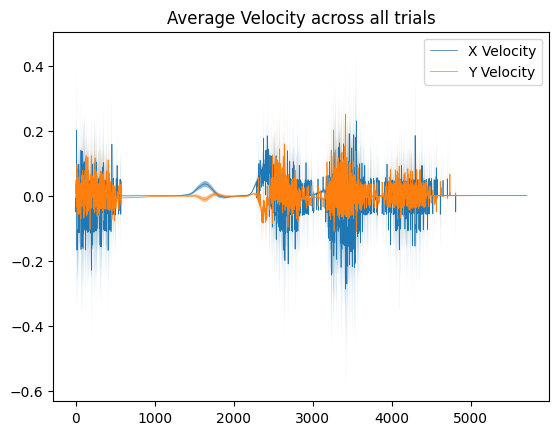

In [ ]:
for trial in range(X.shape[1]):
    spike_times = np.where(X[:, trial, n])[0]
    plt.scatter(spike_times, trial*np.ones(spike_times.size), color='black', s=0.1)
    
for trial in range(X.shape[1]):
    markers = behavioral_markers.iloc[trial].to_numpy()
    plt.scatter(markers, trial*np.ones(markers.size), color=clmap[:markers.size], s=0.1)
for i, marker in enumerate(markers):
    plt.scatter(marker, trial, color=clmap[i], s=0.1, label=marker_labels[i])

plt.title(f'Unit {n} across all trials')
plt.legend(markerscale=8, fontsize='xx-small')
plt.show()

plt.plot(mean_x_vel, linewidth=0.5, label='X Velocity')
plt.fill_between(T, mean_x_vel - x_vel_err, mean_x_vel + x_vel_err, alpha=0.5)
plt.plot(mean_y_vel, linewidth=0.5, label='Y Velocity')
plt.fill_between(T, mean_y_vel - y_vel_err, mean_y_vel + y_vel_err, alpha=0.5)
plt.legend()

plt.title('Average Velocity across all trials')
plt.show()